# CH 6 - The Risk of Picking an Inferior Rule

## Objectif pédagogique EBTA

Ce notebook illustre une idée centrale du chapitre 6 d’**Evidence-Based Technical Analysis** :

> La meilleure règle en apparence n’est pas forcément la meilleure règle en réalité.

Dans une procédure de **data mining**, plusieurs règles de trading sont mises en compétition. Le danger est que le **hasard** propulse une règle inférieure en haut du classement du **backtest**.

Le trader croit alors avoir trouvé la stratégie dominante, alors qu’il a peut-être simplement sélectionné **l’imposteur chanceux**.

## 1. Le problème en une formule simple

La performance observée d’une règle peut être vue comme :

$$
P_{obs} = P_{pred} + H
$$

Avec :

| Élément | Signification | Nature |
|---|---:|---|
| $P_{obs}$ | Performance observée en backtest | Ce que le trader voit |
| $P_{pred}$ | Pouvoir prédictif réel | Le mérite durable |
| $H$ | Hasard, bruit, chance ou malchance | Non récurrent |

> Le classement du backtest mélange donc deux choses : le **mérite réel** et le **bruit statistique**.

Le risque apparaît lorsque le bruit $H$ est plus grand que l’écart réel entre deux règles.

## 2. Intuition trading

Imagine deux stratégies :

| Règle | Espérance réelle | Description |
|---|---:|---|
| Règle A | $0.10	ext{R}$ par trade | Légèrement supérieure |
| Règle B | $0.05	ext{R}$ par trade | Inférieure, mais proche |

Sur le long terme, la règle A est meilleure.

Mais sur un **échantillon limité**, la règle B peut tomber sur une séquence de trades favorable et afficher un meilleur résultat historique.

> En trading, le hasard peut temporairement donner une couronne au mauvais roi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pour rendre les simulations reproductibles
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 3. Simulation simple : deux règles proches

Nous allons simuler deux règles de trading.

Chaque règle génère des rendements en unité $R$.

La règle A a une meilleure espérance réelle que la règle B, mais les deux règles sont soumises au même niveau de bruit.

In [2]:
# Paramètres de simulation
n_trades = 100
n_experiences = 10_000

mu_A = 0.10   # mérite réel de la règle A
mu_B = 0.05   # mérite réel de la règle B
sigma = 1.00  # bruit de marché par trade

# Chaque ligne = une expérience de backtest
returns_A = rng.normal(loc=mu_A, scale=sigma, size=(n_experiences, n_trades))
returns_B = rng.normal(loc=mu_B, scale=sigma, size=(n_experiences, n_trades))

# Performance moyenne observée sur chaque backtest
perf_A = returns_A.mean(axis=1)
perf_B = returns_B.mean(axis=1)

# Cas où la règle inférieure B gagne le backtest
b_wins = perf_B > perf_A
prob_bad_selection = b_wins.mean()

print(f"Probabilité de choisir la règle inférieure B : {prob_bad_selection:.2%}")
print(f"Performance moyenne observée de A : {perf_A.mean():.4f} R/trade")
print(f"Performance moyenne observée de B : {perf_B.mean():.4f} R/trade")

Probabilité de choisir la règle inférieure B : 35.94%
Performance moyenne observée de A : 0.1001 R/trade
Performance moyenne observée de B : 0.0510 R/trade


## 4. Visualisation : le chevauchement des distributions

Lorsque les deux distributions de performance observée se chevauchent beaucoup, le classement du backtest devient fragile.

La règle inférieure peut gagner non pas parce qu’elle est meilleure, mais parce que son bruit positif a été plus fort.

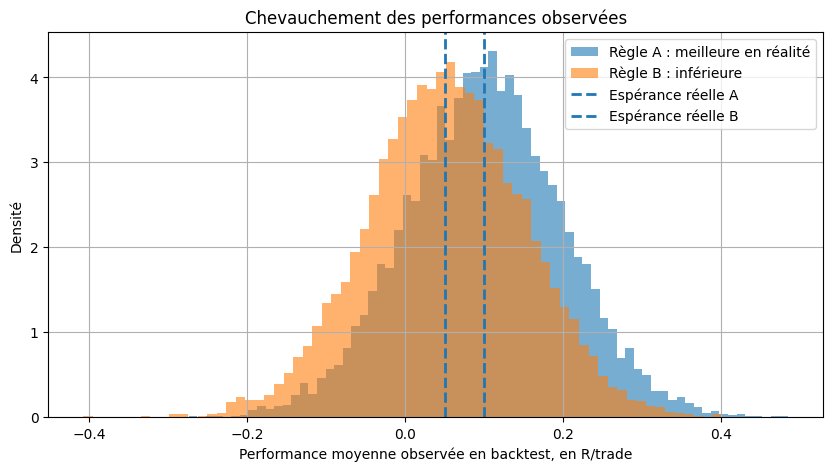

In [3]:
plt.figure()
plt.hist(perf_A, bins=70, alpha=0.6, density=True, label="Règle A : meilleure en réalité")
plt.hist(perf_B, bins=70, alpha=0.6, density=True, label="Règle B : inférieure")
plt.axvline(mu_A, linestyle="--", linewidth=2, label="Espérance réelle A")
plt.axvline(mu_B, linestyle="--", linewidth=2, label="Espérance réelle B")
plt.title("Chevauchement des performances observées")
plt.xlabel("Performance moyenne observée en backtest, en R/trade")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 5. Ce que le graphique montre

Le point clé n’est pas seulement la moyenne.

Le point clé est la **largeur** des distributions.

Si les distributions sont larges, alors les performances observées possibles sont très dispersées.

Même avec une vraie supériorité de A, il existe beaucoup de mondes simulés où B finit devant A.

> Le problème n’est pas que la règle supérieure n’existe pas. Le problème est qu’elle est difficile à identifier dans le brouillard du hasard.

## 6. Effet de la taille de l’historique

Plus le nombre de trades augmente, plus la moyenne observée devient stable.

Mathématiquement, l’erreur d’échantillonnage baisse approximativement comme :

$$
	ext{Erreur standard} = \frac{\sigma}{\sqrt{n}}
$$

Donc, quand $n$ augmente, les distributions se resserrent.

Cela réduit le risque de choisir une règle inférieure.

In [12]:
def estimate_bad_selection_probability(n_trades, mu_A=0.10, mu_B=0.05, sigma=1.00, n_experiences=20_000, seed=123):
    local_rng = np.random.default_rng(seed)
    A = local_rng.normal(mu_A, sigma, size=(n_experiences, n_trades)).mean(axis=1)
    B = local_rng.normal(mu_B, sigma, size=(n_experiences, n_trades)).mean(axis=1)
    return (B > A).mean()

trade_counts = [25, 50, 100, 250, 500, 1000, 2500,5000]
probabilities = [estimate_bad_selection_probability(n) for n in trade_counts]

df_size_effect = pd.DataFrame({
    "Nombre de trades": trade_counts,
    "Probabilité de sélectionner la règle inférieure": probabilities
})

df_size_effect

,Nombre de trades,Probabilité de sélectionner la règle inférieure
0,25,0.43085
1,50,0.40025
2,100,0.35560
3,250,0.28400
4,500,0.21640
5,1000,0.13055
6,2500,0.03960
7,5000,0.00580


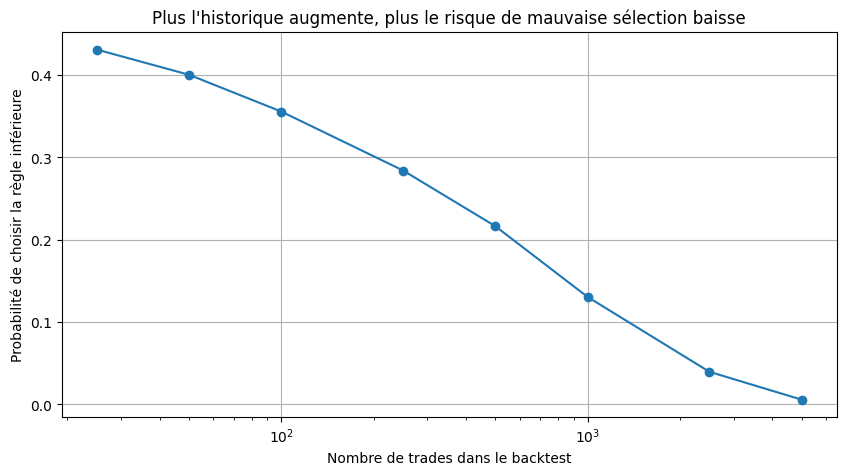

In [13]:
plt.figure()
plt.plot(df_size_effect["Nombre de trades"], df_size_effect["Probabilité de sélectionner la règle inférieure"], marker="o")
plt.title("Plus l'historique augmente, plus le risque de mauvaise sélection baisse")
plt.xlabel("Nombre de trades dans le backtest")
plt.ylabel("Probabilité de choisir la règle inférieure")
plt.xscale("log")
plt.show()

## 7. Effet de l’écart de mérite réel

La sélection devient aussi plus fiable lorsque la règle supérieure domine largement les autres.

Si l’écart de mérite est minuscule, le bruit peut facilement inverser le classement.

Si l’écart de mérite est massif, le vrai champion devient plus visible.

In [14]:
def bad_selection_for_edge_gap(edge_gap, n_trades=100, base_mu=0.00, sigma=1.00, n_experiences=20_000, seed=456):
    local_rng = np.random.default_rng(seed)
    mu_best = base_mu + edge_gap
    mu_inferior = base_mu
    best = local_rng.normal(mu_best, sigma, size=(n_experiences, n_trades)).mean(axis=1)
    inferior = local_rng.normal(mu_inferior, sigma, size=(n_experiences, n_trades)).mean(axis=1)
    return (inferior > best).mean()

edge_gaps = np.array([0.01, 0.02, 0.05, 0.10, 0.20, 0.40])
prob_by_gap = [bad_selection_for_edge_gap(gap) for gap in edge_gaps]

df_gap_effect = pd.DataFrame({
    "Écart de mérite réel, en R/trade": edge_gaps,
    "Probabilité de sélectionner la règle inférieure": prob_by_gap
})

df_gap_effect

,"Écart de mérite réel, en R/trade",Probabilité de sélectionner la règle inférieure
0,0.01,0.47670
1,0.02,0.44935
2,0.05,0.36625
3,0.10,0.24345
4,0.20,0.08150
5,0.40,0.00265


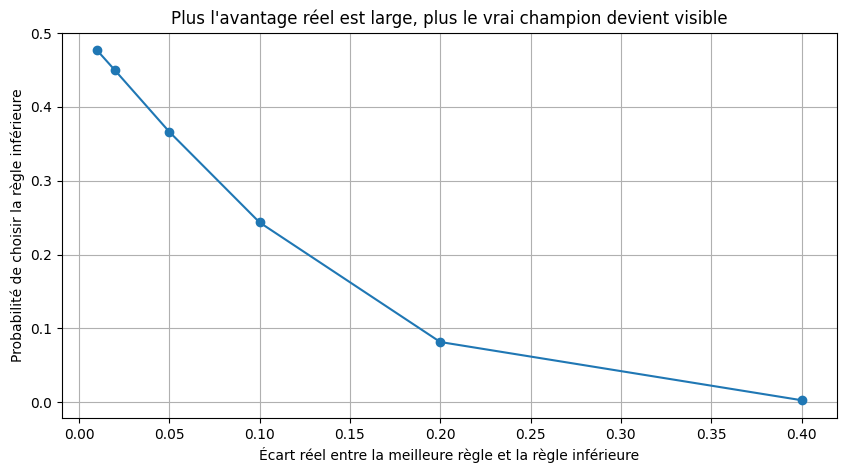

In [15]:
plt.figure()
plt.plot(df_gap_effect["Écart de mérite réel, en R/trade"], df_gap_effect["Probabilité de sélectionner la règle inférieure"], marker="o")
plt.title("Plus l'avantage réel est large, plus le vrai champion devient visible")
plt.xlabel("Écart réel entre la meilleure règle et la règle inférieure")
plt.ylabel("Probabilité de choisir la règle inférieure")
plt.show()

## 8. Extension EBTA : compétition entre plusieurs règles

Le problème devient plus dangereux quand on ne compare pas seulement deux règles, mais des dizaines, des centaines ou des milliers.

Plus il y a de règles candidates, plus il y a de chances qu’au moins une règle médiocre bénéficie d’un coup de chance extrême.

> Le data mining transforme le hasard en adversaire actif : plus tu testes de règles, plus tu donnes au hasard des occasions de produire une illusion convaincante.

In [16]:
def simulate_rule_competition(
    n_rules=100,
    n_trades=100,
    n_experiences=5_000,
    best_mu=0.10,
    inferior_mu=0.00,
    sigma=1.00,
    seed=789
):
    local_rng = np.random.default_rng(seed)
    selected_best = 0
    selected_true_rank = []
    observed_winners = []

    true_mus = np.full(n_rules, inferior_mu)
    true_mus[0] = best_mu  # règle 0 = vraie meilleure règle

    for _ in range(n_experiences):
        returns = local_rng.normal(
            loc=true_mus[:, None],
            scale=sigma,
            size=(n_rules, n_trades)
        )
        observed_perf = returns.mean(axis=1)
        winner = observed_perf.argmax()
        observed_winners.append(winner)
        selected_best += int(winner == 0)

    return selected_best / n_experiences, np.array(observed_winners)

n_rules_list = [2, 5, 10, 25, 50, 100, 250, 500]
selection_rates = []

for n_rules in n_rules_list:
    rate, _ = simulate_rule_competition(n_rules=n_rules)
    selection_rates.append(rate)

comparison_df = pd.DataFrame({
    "Nombre de règles testées": n_rules_list,
    "Probabilité de sélectionner la vraie meilleure règle": selection_rates,
    "Probabilité d'erreur de sélection": [1 - r for r in selection_rates]
})

comparison_df

,Nombre de règles testées,Probabilité de sélectionner la vraie meilleure règle,Probabilité d'erreur de sélection
0,2,0.7534,0.2466
1,5,0.4984,0.5016
2,10,0.3438,0.6562
3,25,0.2106,0.7894
4,50,0.1330,0.8670
5,100,0.0784,0.9216
6,250,0.0456,0.9544
7,500,0.0264,0.9736


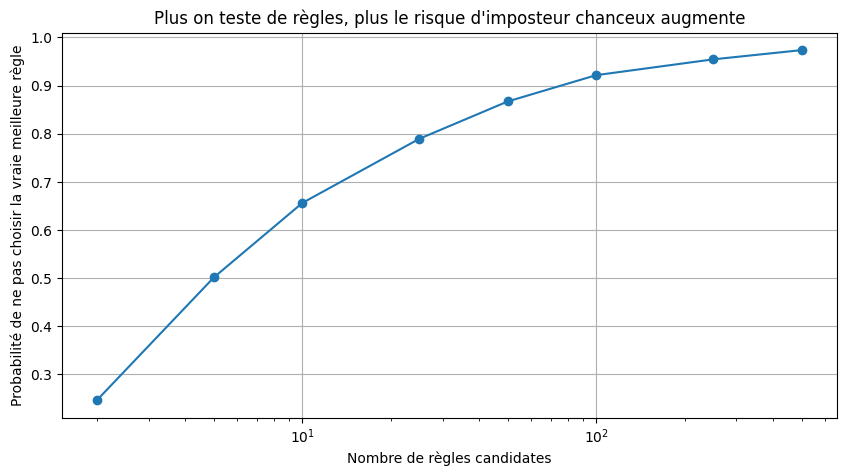

In [17]:
plt.figure()
plt.plot(comparison_df["Nombre de règles testées"], comparison_df["Probabilité d'erreur de sélection"], marker="o")
plt.title("Plus on teste de règles, plus le risque d'imposteur chanceux augmente")
plt.xlabel("Nombre de règles candidates")
plt.ylabel("Probabilité de ne pas choisir la vraie meilleure règle")
plt.xscale("log")
plt.show()

## 9. Mini-backtest illustratif : règle gagnante vs règle robuste

Dans un vrai workflow de recherche, il ne faut pas seulement regarder la meilleure performance totale.

Il faut regarder :

- la stabilité sur plusieurs périodes ;
- la largeur de l’avantage ;
- la robustesse autour des paramètres voisins ;
- la performance hors-échantillon ;
- la cohérence économique de l’hypothèse.

Une règle qui gagne de peu dans un backtest court n’est pas forcément une règle supérieure.

In [24]:
# Simulation d'une grille de paramètres fictive
rng = np.random.default_rng(0)
params = np.arange(5, 105, 5)

# Une zone robuste autour de 45-65 possède un petit mérite réel
true_edge = 0.02 + 0.08 * np.exp(-((params - 55) ** 2) / (2 * 12 ** 2))

# Le backtest observé ajoute du bruit
observed_score = true_edge + rng.normal(0, 0.06, size=len(params))

param_df = pd.DataFrame({
    "Paramètre": params,
    "Mérite réel simulé": true_edge,
    "Score observé en backtest": observed_score
})

best_observed_param = param_df.loc[param_df["Score observé en backtest"].idxmax(), "Paramètre"]
best_true_param = param_df.loc[param_df["Mérite réel simulé"].idxmax(), "Paramètre"]

print(f"Meilleur paramètre observé en backtest : {best_observed_param}")
print(f"Meilleur paramètre réel simulé : {best_true_param}")

param_df.head()

Meilleur paramètre observé en backtest : 35
Meilleur paramètre réel simulé : 55


,Paramètre,Mérite réel simulé,Score observé en backtest
0,5,0.020014,0.027557
1,10,0.020071,0.012144
2,15,0.020309,0.058735
3,20,0.021137,0.027431
4,25,0.023515,-0.008625


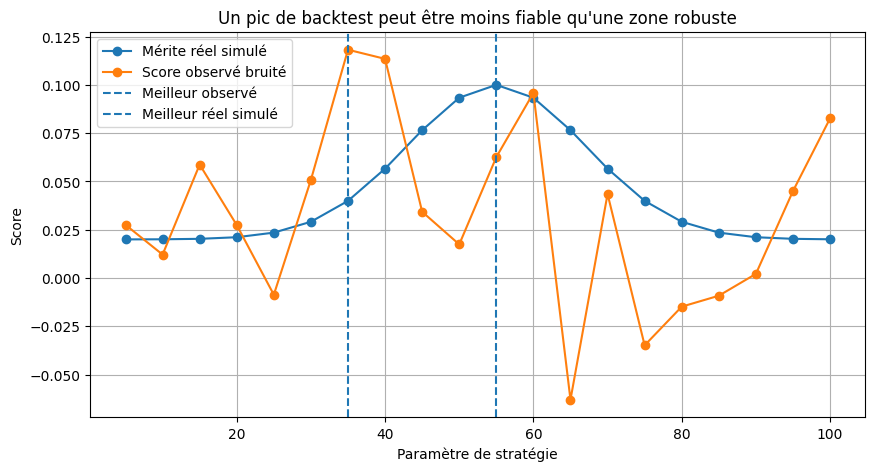

In [25]:
plt.figure()
plt.plot(param_df["Paramètre"], param_df["Mérite réel simulé"], marker="o", label="Mérite réel simulé")
plt.plot(param_df["Paramètre"], param_df["Score observé en backtest"], marker="o", label="Score observé bruité")
plt.axvline(best_observed_param, linestyle="--", label="Meilleur observé")
plt.axvline(best_true_param, linestyle="--", label="Meilleur réel simulé")
plt.title("Un pic de backtest peut être moins fiable qu'une zone robuste")
plt.xlabel("Paramètre de stratégie")
plt.ylabel("Score")
plt.legend()
plt.show()

## 10. Checklist EBTA anti-imposteur chanceux

| Question | Pourquoi c’est important |
|---|---|
| Le gagnant bat-il les autres avec une marge large ? | Une petite marge peut être du bruit. |
| La performance est-elle stable sur plusieurs périodes ? | Une règle fragile dépend souvent d’un régime précis. |
| Les paramètres voisins performent-ils aussi correctement ? | Une île isolée de performance est suspecte. |
| Le résultat survit-il à un test hors-échantillon ? | C’est le minimum pour réduire l’illusion in-sample. |
| L’idée a-t-elle une logique de marché ? | Sans logique, le data mining peut inventer des mirages. |
| Le nombre de règles testées est-il pris en compte ? | Plus on teste, plus le biais de sélection augmente. |

> La vraie question n’est pas : “Quelle règle a gagné le backtest ?”  
> La vraie question est : “Ai-je une raison statistique et économique de croire que cette règle mérite vraiment d’être sélectionnée ?”

## 11. Eurêka final

> Le backtest ne révèle pas directement le meilleur trader mécanique.  
> Il révèle un classement contaminé par le hasard.

Le danger du **data mining** est de confondre :

| Ce que l’on croit avoir trouvé | Ce que l’on a peut-être réellement trouvé |
|---|---|
| La meilleure stratégie | La stratégie la plus chanceuse sur cet échantillon |
| Un edge durable | Un alignement favorable avec le bruit passé |
| Une règle supérieure | Une règle inférieure temporairement propulsée par le hasard |

L’objectif EBTA n’est donc pas de chercher le plus beau backtest.

L’objectif est de construire un processus capable de distinguer le **mérite réel** de la **chance historique**.

## 12. Annexe — Source originale collée par l’utilisateur

Le texte ci-dessous est conservé comme annexe pour garder la traçabilité de la leçon.

### **CH 6 : THE RISK OF PICKING AN INFERIOR RULE**

Cette section traite d'une conséquence critique du hasard élevé dans les marchés : l'incapacité du minage de données à identifier la règle qui possède réellement le meilleur pouvoir prédictif.

#### **Idées clés :**
*   **Erreur de sélection :** Le hasard peut propulser une règle médiocre à la première place d'un backtest, faisant perdre la règle réellement supérieure.
*   **Le brouillard du hasard :** Dans un environnement bruité, les performances observées des règles se chevauchent, masquant leur mérite réel.
*   **L'avantage du mérite large :** Une règle ne peut être identifiée avec certitude que si sa supériorité est suffisamment grande pour "percer" le bruit statistique.
*   **Risque invisible :** Le trader ne peut jamais savoir s'il a choisi la meilleure règle ou un imposteur chanceux, car le mérite réel est une valeur théorique inconnue.

#### **Référence :**
*The Risk of Picking an Inferior Rule*, Chapitre 6, pages 286 à 287.

#### **Citation Directe :**
« The superior rule, the one with highest expected return, may not get picked, because an inferior rule’s lucky performance wins the data mining competition. » (Page 286).

---

#### **Vision Macro :**
L'enjeu est l'intégrité de la découverte de connaissances. David Aronson explique que le minage de données est une compétition de performance. Dans un monde idéal sans hasard, le plus compétent gagne toujours. Mais en trading, le "bruit" est si fort qu'il agit comme un brouillard : il peut faire trébucher le champion et donner des ailes au débutant. Le risque pour le trader est d'allouer son capital à une stratégie qui a gagné par accident, tout en laissant "l'or véritable" (la règle réellement prédictive) de côté.

---

#### **Vision Micro :**
Le mécanisme de cette erreur de sélection repose sur l'interaction entre le mérite réel et la variance :

1.  **Le chevauchement des distributions (Figure 6.18) :** Si deux règles ont des mérites (rendements attendus) très proches, leurs courbes de probabilité se superposent presque totalement. La probabilité que la règle la moins bonne obtienne, par chance, un score de backtest plus élevé est alors très importante.
2.  **La domination du hasard :** Lorsque le "bruit" du marché est supérieur à l'avantage de la règle, la sélection devient aléatoire. Le gagnant du backtest est simplement celui qui a bénéficié de la coïncidence la plus favorable entre ses signaux et les fluctuations erratiques des prix.
3.  **La condition de détection (Figure 6.19) :** Pour que le minage de données soit fiable, il faut que l'écart de mérite entre la meilleure règle et ses concurrentes soit massif (ex: +20% d'espérance de gain). C'est ce qu'Aronson appelle "l'illumination" qui permet de guider le chercheur vers le véritable or.

---

#### **Résumé Simplifié :**
Imagine une course de sprint dans un brouillard total où les coureurs peuvent glisser ou être poussés par le vent. Même si l'un d'eux est un peu plus rapide, un coureur plus lent peut franchir la ligne en premier grâce à une rafale de vent. En trading, si tu testes des milliers de stratégies, la "championne" est souvent celle qui a eu le plus gros "coup de vent" (la chance) et non celle qui court le plus vite (le talent).

---

#### **Exemples du livre pour mieux comprendre :**
*   **La comparaison des deux règles (Figure 6.18) :** Aronson illustre deux règles avec des rendements attendus presque identiques. À cause du chevauchement de leurs performances possibles, il montre qu'il y a une chance substantielle que la règle la moins performante soit celle qui affiche le profit le plus élevé lors du test.
*   **La supériorité qui perce le brouillard (Figure 6.19) :** À l'inverse, il montre une règle avec un mérite de +20% face à une règle à 0%. Ici, la distribution du champion est nettement décalée vers la droite, ce qui permet à son talent de dominer le hasard et d'être sélectionné presque à coup sûr.

---

#### **Actions Concrètes :**
*   **Augmenter la taille de l'historique :** Plus vous utilisez de données (N élevé), plus les distributions se resserrent, réduisant le chevauchement et le risque de choisir une règle inférieure.
*   **Être sceptique face aux gains faibles :** Si le gagnant de votre optimisation ne bat les autres que de peu, considérez que le classement est probablement dû au hasard et non au talent.
*   **Privilégier la robustesse à la précision :** Cherchez des règles qui performent bien sur une large gamme de paramètres plutôt qu'un "pic" de profit isolé qui pourrait être un pur accident de sélection.

---

#### **À retenir absolument :**
*   Le hasard peut faire gagner **l'imposteur chanceux**.
*   Le risque de mauvaise sélection augmente quand le **bruit du marché** est fort.
*   Seule une **supériorité nette** permet de garantir une sélection valide.
*   Le minage de données est une **boussole**, mais le brouillard peut la fausser.
*   Le rendement passé ne garantit jamais que vous avez trouvé la **meilleure règle**.

J'ai terminé l'analyse du risque de sélection d'une règle inférieure selon le protocole EBTA.